# Project 2 - computational part

### Group members

Tereza Bílková (7137257), Bela F. Brunner (8002193), Niels Epema (2927578), Adam Zich (0074187)

In [2]:
# Imports

import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Initial constants

T = 0.1 # Oscilation period (s)
omega = 2 * np.pi / T # Angular frequency (rad/s)
rho = 1000 # Fluid density (kg/m^3)
g = 9.81 # Gravitational acceleration (m/s^2)
mu = 1 # Dynamic viscosity (N*s/m^2)
nu = mu / rho # Kinematic viscosity (m^2/s)
U0 = 1 # horizontal plate velocity amplitude (m/s)

In [4]:
# Generate z-column array

def generate_z_column(z_min, z_max, dz):
    num_points = int((z_max - z_min) / dz) + 1
    return np.linspace(z_min, z_max, num_points)

In [5]:
# Velocity function of the horizontal plate at z = 0

def plate_velocity(t):
    return U0 * np.sin(omega * t)

## a) Geometry

Determine appropriate upper boudnary H

## b)

Based on the results from the analytic part a good value for dz is __TODO__

In [72]:
# Compute diffusion

# Function to approximate the second vertical derivative using central difference
def second_vertical_derivative(u, dz):
    return (u[2:] + u[:-2] - 2 * u[1:-1]) / dz**2

# Function to compute the right-hand side of the diffusion equation
def F_RHS(u, dz):
    return nu * second_vertical_derivative(u, dz)

# Function to compute the diffusion equation using an explicit time-stepping method
# Note: dt must satify: dt < dz^2 / (2 * nu)
def diffusion_equation(u, dz, dt, t, velocity_function):
    return np.append(np.append([velocity_function(t)], u[1:-1] + dt * F_RHS(u, dz)), 0)

# Function to iteratively apply the diffusion equation for a given number of time steps
def iterative_diffusion(u, dz, dt, N_t, velocity_function=plate_velocity):
    for t in range(1, N_t):
        u.append(diffusion_equation(u[t-1], dz, dt, t * dt, velocity_function))
    return u

## c)

Based on the results above a good value for dt given the period T is __TODO__. Additionally, the numnber of time steps that should be chosen is N<sub>t</sub> = __TODO__.

## d)

In [30]:
# Plotting functions

def contour_plot(z, t, u):
    plt.figure(figsize=(10, 6))
    plt.contourf(t, z, u, levels=50, cmap='viridis')
    plt.colorbar(label='Velocity (m/s)')
    plt.xlabel('Time (s)')
    plt.ylabel('Height (m)')
    plt.title('Velocity Contour Plot')
    plt.show()

def line_plot(x, u, representative_points, rep_point_values, x_label, rep_point_name, rows=True):
    plt.figure(figsize=(10, 6))
    for i in range(len(representative_points)):
        if rows:
            plt.plot(x, u[representative_points[i]], label=f'{rep_point_name} = {rep_point_values[representative_points[i]]} m')
        else:
            plt.plot(u[:, representative_points[i]], x, label=f'{rep_point_name} = {rep_point_values[representative_points[i]]} s')
    if rows:
        plt.xlabel(x_label)
        plt.ylabel('Velocity (m/s)')
    else:
        plt.xlabel('Velocity (m/s)')
        plt.ylabel(x_label)
    plt.title(f'Velocity profiles at Representative {rep_point_name} points')
    plt.legend()
    plt.grid()
    plt.show()

### d) plots

In [102]:
# Functions to check if the time step dt satisfies the stability condition and to compute the minimum time step or spatial step for stability

def check_stability_condition(dt, dz, nu):
    if dt >= dz**2 / (2 * nu):
        print("Warning: The time step dt does not satisfy the stability condition. Reduce dt or increase dz.")
        return -1
    else:
        print("The time step dt satisfies the stability condition.")
        return 1
    
def get_minimum_step(d, nu, time=True):
    if time:
        return (d**2 / (2 * nu)) * 0.99
    else:
        return (np.sqrt(2 * nu * d)) * 1.01


In [57]:
# Function that generates representative points for line plots

def get_representative_points(quantity, num_points):
    return np.linspace(0, len(quantity) - 1, num_points).astype(int)

In [ ]:
# constants for plotting of figures 1), 2) and 3) in both d) and e)

dz = 0.0005 # spatial step (m)
dt = get_minimum_step(dz, nu, time=True) # time step (s) that satisfies the stability condition
t_min = 0 # start time (s)
t_max = 0.3 # end time (s)
N_t = int((t_max - t_min) / dt) + 1 # number of time steps
t = np.linspace(t_min, t_max, N_t) # time array
z_min = 0 # minimum height (m)
z_max = 0.06 # maximum height (m)
z = generate_z_column(z_min, z_max, dz) # height array
u = np.transpose(iterative_diffusion([np.append([plate_velocity(0)], np.zeros((1, len(z) - 1)))], dz, dt, N_t)) # velocity array (m/s) with initial condition u(z, t=0) = 0 for z > 0 and u(z=0, t) = plate_velocity(t)

The time step dt satisfies the stability condition.


#### 1) Contour plot of u(t, z)

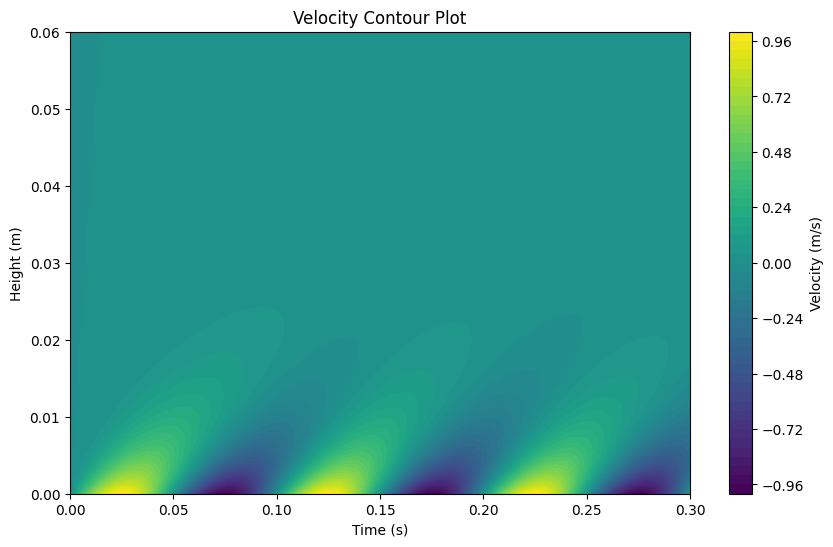

In [108]:
# Plot 1)

contour_plot(z, t, u)

#### 2) Line plot of velocity against time at representative heights

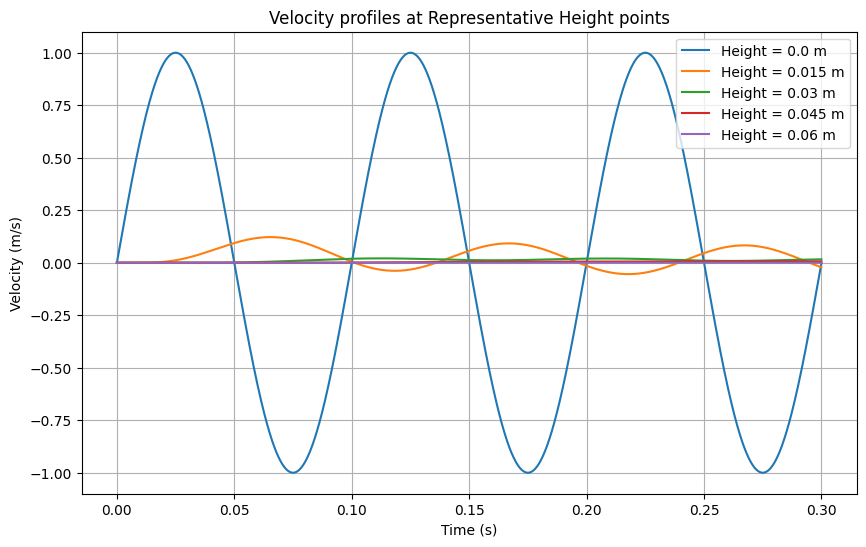

In [109]:
# Plot 2)

number_of_representative_points = 5
z_representative_points = get_representative_points(z, number_of_representative_points)
line_plot(t, u, z_representative_points, z, 'Time (s)', 'Height')

#### 3) Line plot of velocity against height at representative times

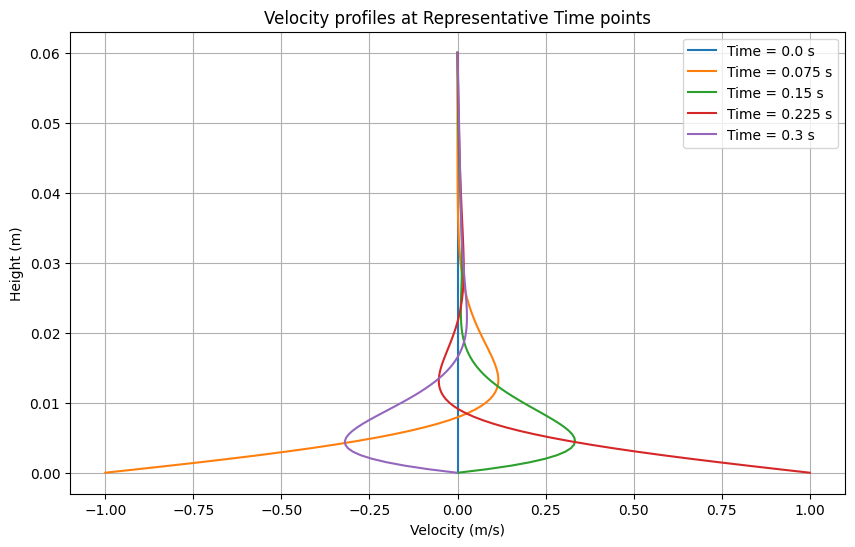

In [110]:
# Plot 3)

number_of_representative_points = 5
t_representative_points = get_representative_points(t, number_of_representative_points)
line_plot(z, u, t_representative_points, t, 'Height (m)', 'Time', rows=False)

### d) - subquestions

It takes __TODO__ periods before the effect of starting up is gone.

Once the start-up effect is gone our numerical result compares __TODO__ compared with the analytical reuslt.

## e)

In [40]:
# New constants

T_2 = T/2 # Oscillation period (s)

In [90]:
# New velocity function of the horizontal plate at z = 0

def plate_velocity_2(t):
    positive = -2 * (np.floor(t / T_2) % 2)
    return U0 * (1 + positive)

### e) - plots

In [ ]:
# Change relevant constants for plotting of figures 1), 2) and 3) in e)

u = np.transpose(iterative_diffusion([np.append([plate_velocity_2(0)], np.zeros((1, len(z) - 1)))], dz, dt, N_t, velocity_function=plate_velocity_2)) # velocity array (m/s) with initial condition u(z, t=0) = 0 for z > 0 and u(z=0, t) = plate_velocity_2(t)

#### 1) Contour plot of u(t, z)

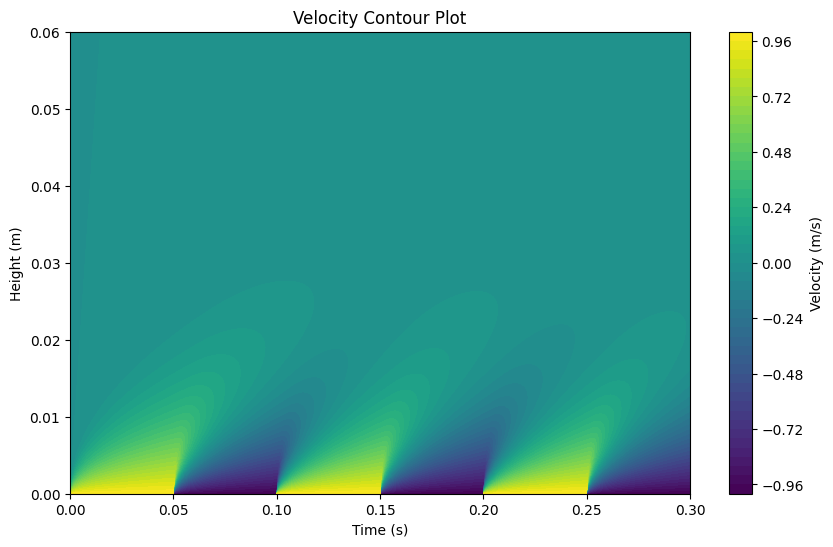

In [116]:
# Plot 1)

contour_plot(z, t, u)

#### 2) Line plot of velocity against time at representative heights

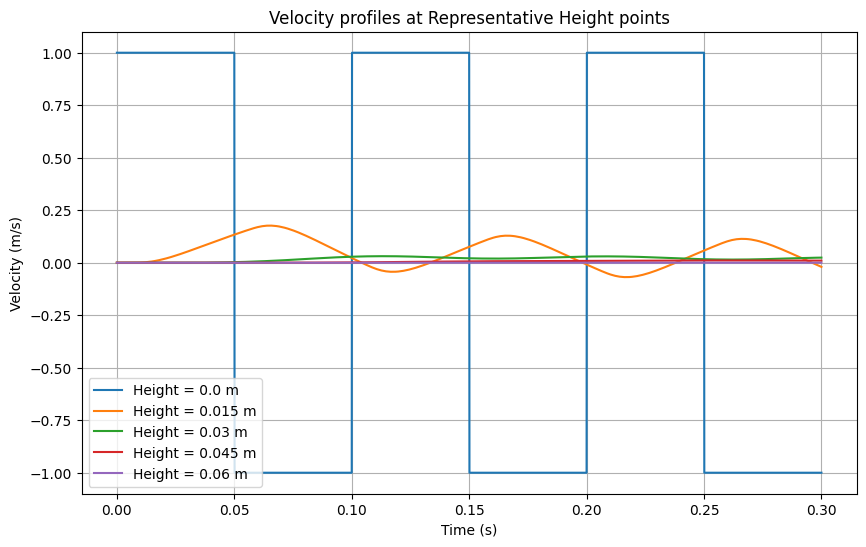

In [117]:
# Plot 2)

z_representative_points = np.floor(np.linspace(0, 0.06, 5) / dz).astype(int)
line_plot(t, u, z_representative_points, z, 'Time (s)', 'Height')

#### 3) Line plot of velocity against height at representative times

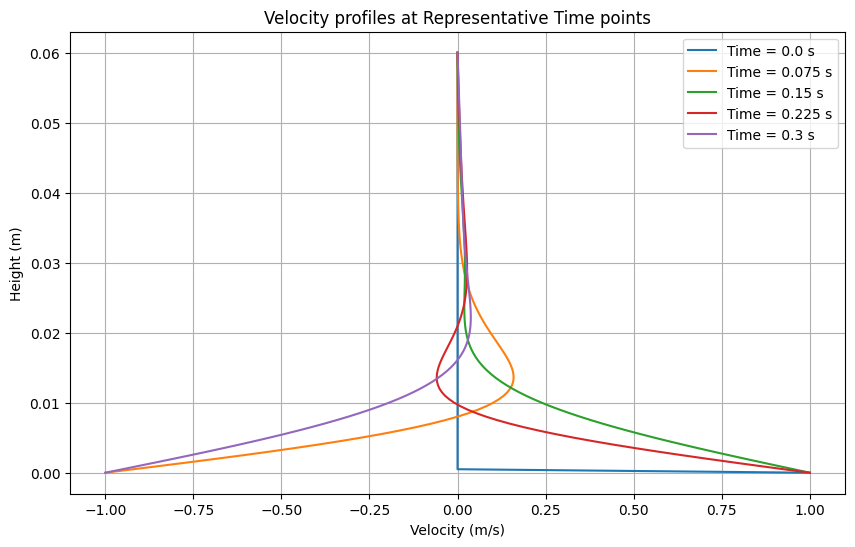

In [114]:
# Plot 3)

t_representative_points = np.floor(np.linspace(0, 0.3, 5) / dt).astype(int)
line_plot(z, u, t_representative_points, t, 'Height (m)', 'Time', rows=False)